## Persistence
Ability to save the state of the workflow overtime including initial, and intermediate states in a Database or RAM

This is done to achieve:
* `Short Term Memory` if the workflow was terminated and needs to be revived and continued from the same place where it was terminated
*  `Fault Tolerence` if the workflow encounters an error and gets terminated it can be continued again from the last successfully executed state after resolving the issues
* `Human in the Loop` asks the user for permissions or reviews
* `Time Travel` halts the workflow if needed and can continue from the same state again later.Also can be used to go back to particular state and restart from there, like creating a separate branch with different inputs and outputs

Other concepts like `thread_id` and `Checkpointers` are also used to achieve this

* `Thread_id`: assign a unique thread id to each workflow execution so that using the same id, the conversation can be resumed again later
* `Checkpointers`: records all the changes made in a suoerstate across all states throughout the workflows execution 

In [1]:
#libraries
from langgraph.graph import StateGraph, START, END
from typing import TypedDict
from langchain_google_genai import ChatGoogleGenerativeAI
from dotenv import load_dotenv
from langgraph.checkpoint.memory import InMemorySaver

In [2]:
load_dotenv()

True

In [3]:
llm=ChatGoogleGenerativeAI(
    model='gemini-3.1-flash-lite'
)

In [4]:

class JokeState(TypedDict):

    topic: str
    joke: str
    explanation: str

In [5]:
def generate_joke(state: JokeState):

    prompt = f'generate a joke on the topic {state["topic"]}'
    response = llm.invoke(prompt).content

    return {'joke': response}

def generate_explanation(state: JokeState):

    prompt = f'write an explanation for the joke - {state["joke"]}'
    response = llm.invoke(prompt).content

    return {'explanation': response}

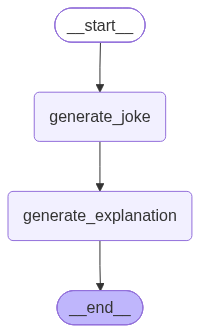

In [7]:

graph = StateGraph(JokeState)

graph.add_node('generate_joke', generate_joke)
graph.add_node('generate_explanation', generate_explanation)

graph.add_edge(START, 'generate_joke')
graph.add_edge('generate_joke', 'generate_explanation')
graph.add_edge('generate_explanation', END)

checkpointer = InMemorySaver() #InMemorySaver saves the records in RAM

workflow = graph.compile(checkpointer=checkpointer)

workflow

In [8]:
config1 = {"configurable": {"thread_id": "1"}}
workflow.invoke({'topic':'ginger cats'}, config=config1)

{'topic': 'ginger cats',
 'joke': [{'type': 'text',
   'text': 'Why do ginger cats always look so confused?\n\nBecause they’re all sharing the same single brain cell, and it’s rarely their turn to use it!',
   'extras': {'signature': 'EjQKMgERTTIPDj/xp/G04gdZGdO52Q/rpKrza5MSxL84fLW0PpmGpmyuUdy3Uve89nHS1j4b'}}],
 'explanation': [{'type': 'text',
   'text': 'This joke plays on a popular internet meme within the cat-owner community. Here is the breakdown of why it’s considered funny:\n\n### 1. The "Single Brain Cell" Theory\nThere is a long-standing, tongue-in-cheek urban legend among cat lovers that orange (ginger) cats are "genetically" linked by a single, collective brain cell that they have to pass back and forth. Because there are millions of ginger cats in the world, the "wait time" to use that one brain cell is incredibly long. \n\n### 2. The Behavior of Ginger Cats\nThe joke stems from the observation that ginger cats often act remarkably silly, clumsy, or bewildered. While there 

In [9]:
workflow.get_state(config1)

StateSnapshot(values={'topic': 'ginger cats', 'joke': [{'type': 'text', 'text': 'Why do ginger cats always look so confused?\n\nBecause they’re all sharing the same single brain cell, and it’s rarely their turn to use it!', 'extras': {'signature': 'EjQKMgERTTIPDj/xp/G04gdZGdO52Q/rpKrza5MSxL84fLW0PpmGpmyuUdy3Uve89nHS1j4b'}}], 'explanation': [{'type': 'text', 'text': 'This joke plays on a popular internet meme within the cat-owner community. Here is the breakdown of why it’s considered funny:\n\n### 1. The "Single Brain Cell" Theory\nThere is a long-standing, tongue-in-cheek urban legend among cat lovers that orange (ginger) cats are "genetically" linked by a single, collective brain cell that they have to pass back and forth. Because there are millions of ginger cats in the world, the "wait time" to use that one brain cell is incredibly long. \n\n### 2. The Behavior of Ginger Cats\nThe joke stems from the observation that ginger cats often act remarkably silly, clumsy, or bewildered. Wh

In [10]:
list(workflow.get_state_history(config1))

[StateSnapshot(values={'topic': 'ginger cats', 'joke': [{'type': 'text', 'text': 'Why do ginger cats always look so confused?\n\nBecause they’re all sharing the same single brain cell, and it’s rarely their turn to use it!', 'extras': {'signature': 'EjQKMgERTTIPDj/xp/G04gdZGdO52Q/rpKrza5MSxL84fLW0PpmGpmyuUdy3Uve89nHS1j4b'}}], 'explanation': [{'type': 'text', 'text': 'This joke plays on a popular internet meme within the cat-owner community. Here is the breakdown of why it’s considered funny:\n\n### 1. The "Single Brain Cell" Theory\nThere is a long-standing, tongue-in-cheek urban legend among cat lovers that orange (ginger) cats are "genetically" linked by a single, collective brain cell that they have to pass back and forth. Because there are millions of ginger cats in the world, the "wait time" to use that one brain cell is incredibly long. \n\n### 2. The Behavior of Ginger Cats\nThe joke stems from the observation that ginger cats often act remarkably silly, clumsy, or bewildered. W

In [12]:

config2 = {"configurable": {"thread_id": "2"}}
workflow.invoke({'topic':'siberian husky'}, config=config2)

{'topic': 'siberian husky',
 'joke': [{'type': 'text',
   'text': 'Why did the Siberian Husky sit on the radiator?\n\nBecause he wanted to have a **hot dog**!',
   'extras': {'signature': 'EjQKMgERTTIP125qkO3NqvwK0msgZaBQWR9W5K7Z/cv4wxM2yKtlmSoYFN39jZVZZJWMlptq'}}],
 'explanation': [{'type': 'text',
   'text': 'This joke is a play on words that relies on a double meaning of the phrase **"hot dog."**\n\nHere is the breakdown of why it is funny:\n\n1.  **The Literal Meaning:** A Siberian Husky is a dog breed that thrives in cold climates. Because they have thick coats and are built for snow, a Husky sitting on a radiator would technically become a dog that is physically hot.\n2.  **The Idiomatic Meaning:** "Hot dog" is the common term for a frankfurter sausage served in a bun. \n\n**The Punchline:** The joke uses the literal situation (a dog getting warm on a radiator) to arrive at the pun "hot dog." It suggests that the dog isn\'t just sitting there to get warm, but is intentionally try

In [13]:

workflow.get_state(config1)

StateSnapshot(values={'topic': 'ginger cats', 'joke': [{'type': 'text', 'text': 'Why do ginger cats always look so confused?\n\nBecause they’re all sharing the same single brain cell, and it’s rarely their turn to use it!', 'extras': {'signature': 'EjQKMgERTTIPDj/xp/G04gdZGdO52Q/rpKrza5MSxL84fLW0PpmGpmyuUdy3Uve89nHS1j4b'}}], 'explanation': [{'type': 'text', 'text': 'This joke plays on a popular internet meme within the cat-owner community. Here is the breakdown of why it’s considered funny:\n\n### 1. The "Single Brain Cell" Theory\nThere is a long-standing, tongue-in-cheek urban legend among cat lovers that orange (ginger) cats are "genetically" linked by a single, collective brain cell that they have to pass back and forth. Because there are millions of ginger cats in the world, the "wait time" to use that one brain cell is incredibly long. \n\n### 2. The Behavior of Ginger Cats\nThe joke stems from the observation that ginger cats often act remarkably silly, clumsy, or bewildered. Wh

In [14]:
list(workflow.get_state_history(config1))

[StateSnapshot(values={'topic': 'ginger cats', 'joke': [{'type': 'text', 'text': 'Why do ginger cats always look so confused?\n\nBecause they’re all sharing the same single brain cell, and it’s rarely their turn to use it!', 'extras': {'signature': 'EjQKMgERTTIPDj/xp/G04gdZGdO52Q/rpKrza5MSxL84fLW0PpmGpmyuUdy3Uve89nHS1j4b'}}], 'explanation': [{'type': 'text', 'text': 'This joke plays on a popular internet meme within the cat-owner community. Here is the breakdown of why it’s considered funny:\n\n### 1. The "Single Brain Cell" Theory\nThere is a long-standing, tongue-in-cheek urban legend among cat lovers that orange (ginger) cats are "genetically" linked by a single, collective brain cell that they have to pass back and forth. Because there are millions of ginger cats in the world, the "wait time" to use that one brain cell is incredibly long. \n\n### 2. The Behavior of Ginger Cats\nThe joke stems from the observation that ginger cats often act remarkably silly, clumsy, or bewildered. W

### Time Travel

In [15]:
workflow.get_state({"configurable": {"thread_id": "1", "checkpoint_id": "1f182dc5-f54c-627a-8000-78811d83afbd"}})

StateSnapshot(values={'topic': 'ginger cats'}, next=('generate_joke',), config={'configurable': {'thread_id': '1', 'checkpoint_id': '1f182dc5-f54c-627a-8000-78811d83afbd'}}, metadata={'source': 'loop', 'step': 0, 'parents': {}}, created_at='2026-07-18T19:10:42.900236+00:00', parent_config={'configurable': {'thread_id': '1', 'checkpoint_ns': '', 'checkpoint_id': '1f182dc5-f547-6446-bfff-f629c21d96f1'}}, tasks=(PregelTask(id='033e74df-4f9c-897f-b376-87dad399d3cc', name='generate_joke', path=('__pregel_pull', 'generate_joke'), error=None, interrupts=(), state=None, result={'joke': [{'type': 'text', 'text': 'Why do ginger cats always look so confused?\n\nBecause they’re all sharing the same single brain cell, and it’s rarely their turn to use it!', 'extras': {'signature': 'EjQKMgERTTIPDj/xp/G04gdZGdO52Q/rpKrza5MSxL84fLW0PpmGpmyuUdy3Uve89nHS1j4b'}}]}),), interrupts=())

In [16]:
# re-running the same thread for different resullt on same topic
workflow.invoke(None, {"configurable": {"thread_id": "1", "checkpoint_id": "1f182dc5-f54c-627a-8000-78811d83afbd"}})

{'topic': 'ginger cats',
 'joke': [{'type': 'text',
   'text': 'Why do ginger cats always have such a laid-back attitude?\n\nBecause they’re all sharing the same **single brain cell**, and it’s usually someone else’s turn to use it.',
   'extras': {'signature': 'EjQKMgERTTIPdxqo4M3iZOmlOLBwYGGoWHqgVFovh0an3TZKwUkBzxTPrOGU2sBOc6Vg8SHe'}}],
 'explanation': [{'type': 'text',
   'text': 'This joke is based on a popular internet meme within the cat-loving community, specifically regarding **orange (ginger) cats**. Here is the breakdown of why it is considered funny:\n\n### 1. The "Orange Cat Energy" Stereotype\nIn online culture, there is a long-standing joke that orange cats are notoriously "not the brightest." While there is no scientific evidence that ginger cats are less intelligent than other cats, they have earned a reputation for being goofy, chaotic, slightly clumsy, and remarkably vacant-eyed.\n\n### 2. The "Single Brain Cell" Theory\nThe core of the joke is the myth that all orang

In [17]:
list(workflow.get_state_history(config1))

[StateSnapshot(values={'topic': 'ginger cats', 'joke': [{'type': 'text', 'text': 'Why do ginger cats always have such a laid-back attitude?\n\nBecause they’re all sharing the same **single brain cell**, and it’s usually someone else’s turn to use it.', 'extras': {'signature': 'EjQKMgERTTIPdxqo4M3iZOmlOLBwYGGoWHqgVFovh0an3TZKwUkBzxTPrOGU2sBOc6Vg8SHe'}}], 'explanation': [{'type': 'text', 'text': 'This joke is based on a popular internet meme within the cat-loving community, specifically regarding **orange (ginger) cats**. Here is the breakdown of why it is considered funny:\n\n### 1. The "Orange Cat Energy" Stereotype\nIn online culture, there is a long-standing joke that orange cats are notoriously "not the brightest." While there is no scientific evidence that ginger cats are less intelligent than other cats, they have earned a reputation for being goofy, chaotic, slightly clumsy, and remarkably vacant-eyed.\n\n### 2. The "Single Brain Cell" Theory\nThe core of the joke is the myth tha

### Updating States

In [18]:
workflow.update_state({"configurable": {"thread_id": "1", "checkpoint_id": "1f182dc5-f54c-627a-8000-78811d83afbd", "checkpoint_ns": ""}}, {'topic':'homelander'})

{'configurable': {'thread_id': '1',
  'checkpoint_ns': '',
  'checkpoint_id': '1f182de6-3a80-606d-8001-65fdae2ea493'}}

In [19]:
list(workflow.get_state_history(config1))

[StateSnapshot(values={'topic': 'homelander'}, next=('generate_joke',), config={'configurable': {'thread_id': '1', 'checkpoint_ns': '', 'checkpoint_id': '1f182de6-3a80-606d-8001-65fdae2ea493'}}, metadata={'source': 'update', 'step': 1, 'parents': {}}, created_at='2026-07-18T19:25:09.150116+00:00', parent_config={'configurable': {'thread_id': '1', 'checkpoint_ns': '', 'checkpoint_id': '1f182dc5-f54c-627a-8000-78811d83afbd'}}, tasks=(PregelTask(id='09353585-e9dc-b456-ec84-c4e664616e5f', name='generate_joke', path=('__pregel_pull', 'generate_joke'), error=None, interrupts=(), state=None, result=None),), interrupts=()),
 StateSnapshot(values={'topic': 'ginger cats', 'joke': [{'type': 'text', 'text': 'Why do ginger cats always have such a laid-back attitude?\n\nBecause they’re all sharing the same **single brain cell**, and it’s usually someone else’s turn to use it.', 'extras': {'signature': 'EjQKMgERTTIPdxqo4M3iZOmlOLBwYGGoWHqgVFovh0an3TZKwUkBzxTPrOGU2sBOc6Vg8SHe'}}], 'explanation': [{'ty

In [20]:

workflow.invoke(None, {"configurable": {"thread_id": "1", "checkpoint_id": "1f182de6-3a80-606d-8001-65fdae2ea493"}})

{'topic': 'homelander',
 'joke': [{'type': 'text',
   'text': 'Why doesn’t Homelander use a therapist?\n\nBecause every time he walks into the office, he just stares at the doctor until they agree that he’s the real hero.',
   'extras': {'signature': 'EjQKMgERTTIPEwtAPO4TystEkgrw8u59kDcsHm+I2kVYEI4DIiP3I3DNptvU/juVHOPdKjTy'}}],
 'explanation': [{'type': 'text',
   'text': 'This joke relies on the core personality traits of **Homelander**, the primary antagonist of the series *The Boys*. Here is an explanation of why it works:\n\n### 1. His Narcissistic Need for Validation\nHomelander is pathologically obsessed with being perceived as a "hero" by the public, despite being a sociopathic murderer. He constantly craves external validation and adoration. The joke plays on the idea that if he were to seek professional help, he wouldn\'t actually be interested in personal growth or mental health; he would use the session as another platform to force someone to worship him.\n\n### 2. His Use o

In [21]:
list(workflow.get_state_history(config1))

[StateSnapshot(values={'topic': 'homelander', 'joke': [{'type': 'text', 'text': 'Why doesn’t Homelander use a therapist?\n\nBecause every time he walks into the office, he just stares at the doctor until they agree that he’s the real hero.', 'extras': {'signature': 'EjQKMgERTTIPEwtAPO4TystEkgrw8u59kDcsHm+I2kVYEI4DIiP3I3DNptvU/juVHOPdKjTy'}}], 'explanation': [{'type': 'text', 'text': 'This joke relies on the core personality traits of **Homelander**, the primary antagonist of the series *The Boys*. Here is an explanation of why it works:\n\n### 1. His Narcissistic Need for Validation\nHomelander is pathologically obsessed with being perceived as a "hero" by the public, despite being a sociopathic murderer. He constantly craves external validation and adoration. The joke plays on the idea that if he were to seek professional help, he wouldn\'t actually be interested in personal growth or mental health; he would use the session as another platform to force someone to worship him.\n\n### 2